In [1]:
import os
os.chdir("/content")
!rm -rf STAT-7220- Applied-Experimental-Design
print(os.getcwd())

/content


In [2]:
import os
os.chdir("/content")
!rm -rf STAT-7220- Applied-Experimental-Design


# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "djuarez7-KSU"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
   print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/Midterm-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/djuarez7-KSU/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/djuarez7-KSU/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam


# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: October 24, 2025**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Counter-Strike) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Answer:**

Our main objective is to determine which controller prototype is better for the comfort of the users.

**Question 2.** Specify the outcome variable

**Answer:**

The outcome variable will be the *level of comfort*.

**Question 3.** Specify the independent variable. What are some possible lurking variables?

**Answer:**

The **IV** for this experiment will be the different type of materials:

  I. Plastic
  
  II. Rubber
  
  III. Silicone
  
  IV. Metal

***Possible Lurking*** variables are: Time that gamers played, the room temperature, the console, just to mentioned some of them.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

**Answer:**

The **CRD** can be implemented because all our experimental units are randomly assigned to a treatmetn and each unit has the same chance of being in one of the 2 treatment groups. As well beacuse our units are homogeneous.

**Question 5.** State the null and alternative hypotheses for this experiment.

**Answer:** $$ H_0: \mu_{\text{plastic}} = \mu_{\text{rubber}} = \mu_{\text{silicone}} = \mu_{\text{metal}} $$

$$ H_1: \text{At least one pair of means differ substantially} $$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Answer:** After checking the initial EDA and creating a visualization, I can infere that the alternative hypothesis is supported for the boxplot; since, we can see a strong overlapping  which potentially indicates that the response pattern between all the material groups may be substantially different.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Material  40 non-null     object 
 1   Comfort   40 non-null     float64
dtypes: float64(1), object(1)
memory usage: 772.0+ bytes
None
  Material  Comfort
0  Plastic      5.6
1  Plastic      5.9
2  Plastic      6.3
3  Plastic      5.7
4  Plastic      5.6
          mean       std
Material                
Metal     4.95  0.538000
Plastic   5.89  0.448330
Rubber    6.57  0.860297
Silicone  8.32  0.689283


Text(0.5, 1.0, 'Comfort by Material')

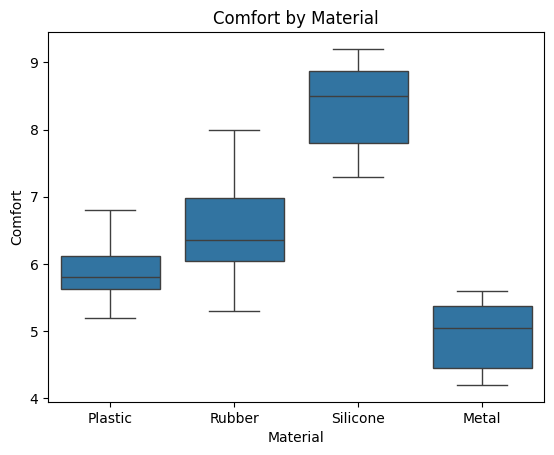

In [9]:
#import neccesary library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#import the data set
controls = pd.read_excel("Video Game Controllers.xlsx")

#data integrity check
print(controls.info())
print(controls.head())

#calculate the mean and std for comfort by material
controls_stat = controls.groupby('Material')["Comfort"].agg(['mean', 'std'])
print(controls_stat)

#generate the visualization
sns.boxplot(x = 'Material', y = 'Comfort', data = controls)

#add labels
plt.xlabel('Material')
plt.ylabel("Comfort")
plt.title("Comfort by Material")




**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a testing and visual method. Do the results of the normality test(s) support the assumption of normality?

**Answer:**
- Our $F_{\text{Stat}} = 47.48$ and has an associated $p-value\space < 0.00001$.
- As we can see, most of the points fall near the line bisecting the graph.

The normality test hypothesis:

$$ H_0: \text{The Normality Assumption is Met} $$

$$ H_1: \text{The Normality Assumption is Not Met} $$

- Here we get both the test statistic ($W=0.99$) as well as its associated p-value ($p=0.95$).

- Since $p > \alpha = 0.05$, this tells us the data more strongly support the  **null hypothesis**, meaning that the assumption of normality is supported by the data.

We can conclude that the testing method as well the QQ plot support that the assumptions follow a normal distribution.

            df    sum_sq    mean_sq          F        PR(>F)
Material   3.0  60.73675  20.245583  47.478405  1.348029e-12
Residual  36.0  15.35100   0.426417        NaN           NaN


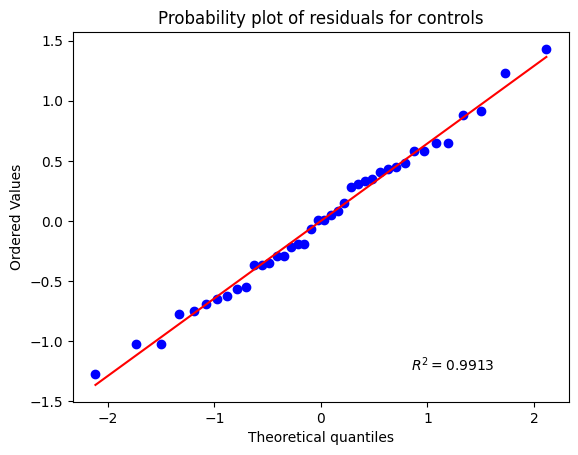

Shapiro-Wilk test statistic: 0.9884713563029021, p-value: 0.9509274348395812


In [13]:
#import libaries for ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
import matplotlib.pyplot as plt

#fit One-Way ANOVA model
control_model = ols('Comfort~Material', data = controls).fit()

print(sm.stats.anova_lm(control_model, typ = 1))

#extract residuals
residuals_controls = control_model.resid

#create a QQ plot for residuals
normality_plot, stats_output = stats.probplot(residuals_controls, plot = plt, rvalue = True)
plt.title("Probability plot of residuals for controls")
plt.show()

#perfom a Shapiro-Wilks test of normality
shapiro_test = stats.shapiro(residuals_controls)
print(f"Shapiro-Wilk test statistic: {shapiro_test.statistic}, p-value: {shapiro_test.pvalue}")

**Question 8.** Test the assumption of homogeneity of variance using **both** a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Answer:**
- For each material mean, the residuals are mostly centered around 0, which implies that the residual mean being approximately 0 seems reasonable.

- Additionally, while the residuals are not exactly the same width, they are not drastically different either.

State the statistical hypothesis for the inferential test:

$$ H_0: \text{Variance is Constant} $$

$$ H_1: \text{Variance is Not Constant} $$

- Since our p-value > 0.05, the data more strongly support the  **null hypothesis**.

Since the scatterplot of standardized residuals to fitted values looked reasonably good and the test support the **null hypothesis**, we can feel comfortable assuming the data support the constant variance assumption.


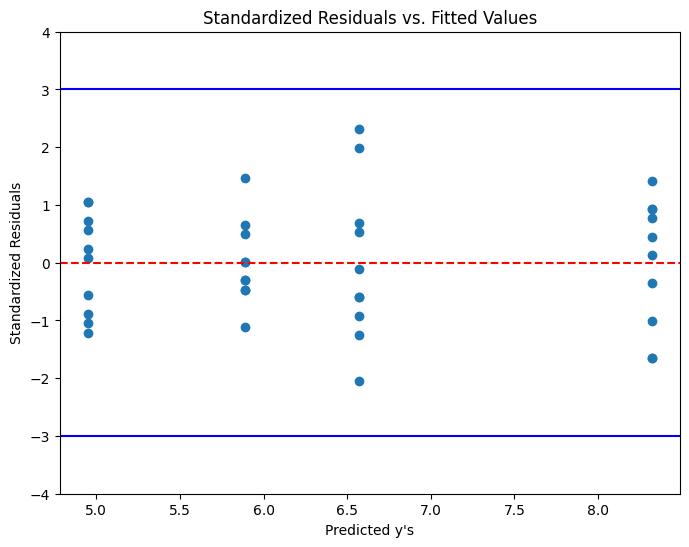

F-statistic: 2.200888430898914
P-value: 0.10479321791365742


In [14]:
#obtain standardized residuals
standardized_residuals = control_model.get_influence().resid_studentized_internal

#get fitted values
fitted_values = control_model.fittedvalues

#create a plot
plt.figure(figsize =(8, 6))
plt.scatter(fitted_values, standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

#implement Bruesch-Pagan test
from statsmodels.stats.diagnostic import het_breuschpagan

#run the test
bp_test = het_breuschpagan(control_model.resid, control_model.model.exog)

#extract the F-statistics and the P-values
f_statistic = bp_test[2]
f_p_value = bp_test[3]

#print the results
print(f"F-statistic: {f_statistic}")
print(f"P-value: {f_p_value}")


**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?

**Answer:**

The **alternative hypothesis** is more strongly supported since our $p-value < 0.05$. this suggests the **rejection of the null hypothesis**.

In [15]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

#lets fit One-Way ANOVA model
control_model = ols('Comfort~Material', data = controls).fit()

print(sm.stats.anova_lm(control_model, typ= 1))

            df    sum_sq    mean_sq          F        PR(>F)
Material   3.0  60.73675  20.245583  47.478405  1.348029e-12
Residual  36.0  15.35100   0.426417        NaN           NaN


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Answer:**

- These results, as shown by the adjusted $p < 0.05$, indicate that the mean rating for rubber and plastic is the only treatment group not significant ($p > 0.05$) in our experiment, founding a statistically difference between the comfort in the remaining groups.

In [16]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test ##
tukey_result = pairwise_tukeyhsd(endog=controls['Comfort'], groups=controls['Material'],
                                 alpha=0.05)

print(tukey_result)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.94 0.0139  0.1535 1.7265   True
  Metal   Rubber     1.62    0.0  0.8335 2.4065   True
  Metal Silicone     3.37    0.0  2.5835 4.1565   True
Plastic   Rubber     0.68 0.1104 -0.1065 1.4665  False
Plastic Silicone     2.43    0.0  1.6435 3.2165   True
 Rubber Silicone     1.75    0.0  0.9635 2.5365   True
------------------------------------------------------


**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses.

**Answer:**

Our experimental analysis showed enough stastical proof to infer that the majority of the materials used in the controlls have statistical impact to modify the comfort levels, so depending in which level of comfort we are looking to have it will depend on the material we will use.  

**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Answer:**

Identify how different methods impact the score of students in their 50 test question to measure attitudes toward elderly people.

**Question 2.** Specify the outcome variable

**Answer:**

The outcome variable will be the score result.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

**Answer:**

The *independent variable (IV)* is the different **methods** that in our case is a categorical and nominal variable with the values:

- Traditional

- VR

The *lurking variables* could be:

- Student's prior experience working with elderly people.

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

**Answer:**

Since our experiment include the variable **Prior Experience** (*no prior and prior experience*) make the units not homogeneous, and that's why Random Block Design (*RBD*) is appropiate for the experiment.

**Question 5.** State the null and alternative hypotheses for this experiment.

**Answer:**

$$ H_0: \mu_{\text{vr}} = \mu_{\text{traditional}}$$

$$ H_1: \text{At least one pair of means differ substantially} $$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Answer:**

After checking the initial EDA and creating a visualization, I can infere that the **null hypothesis** isn't supported for the boxplots; since, we can see slighty overlapping between some groups but not in all of them, which potentially indicates that all the means differ from each teaching method.






<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Method      40 non-null     object
 1   Experience  40 non-null     object
 2   Score       40 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB
None
                                 mean       std
Experience          Method                     
No Prior Experience Traditional  31.5  5.060742
                    VR           40.3  6.183311
Prior Experience    Traditional  31.1  6.505553
                    VR           41.2  7.857056


Text(0.5, 1.0, 'Effect of Methods on Scores')

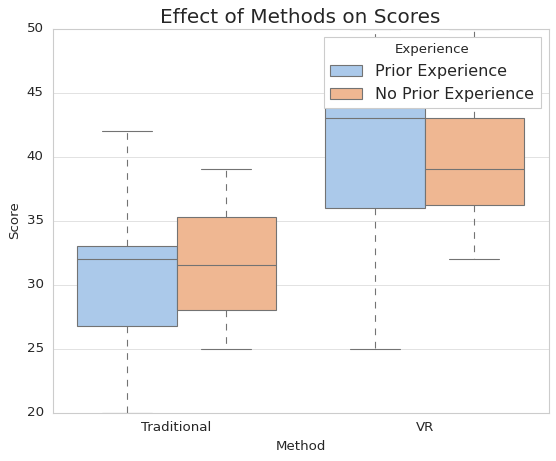

In [19]:
#Import the neccesary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#Load the dataset
vr = pd.read_excel('Nursing VR Study.xlsx')

#Check dataset
print(vr.info())

#EDA means and standard deviations
#using our blocking factor --> Prior Knowledge
# and our IV --> Teaching Method
stats = vr.groupby(['Experience','Method'])['Score'].agg(['mean', 'std'])
print(stats)

#Plot to have a vizualitation
sns.set_style('whitegrid')

sns.boxplot(
    data =  vr,
    x = 'Method',
    y = "Score",
    hue = 'Experience',
    palette= 'pastel'
)

plt.title("Effect of Methods on Scores",
          loc = 'center',
          fontsize = 18)

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Answer:**

Since the *p-value* of the Shapiro-Wilk test is grater than *0.05*, we fail to reject the null hypothesis so normality assumption is met for this experiment.

              sum_sq    df          F    PR(>F)
Method       893.025   1.0  21.805174  0.000039
Experience     0.625   1.0   0.015261  0.902353
Residual    1515.325  37.0        NaN       NaN


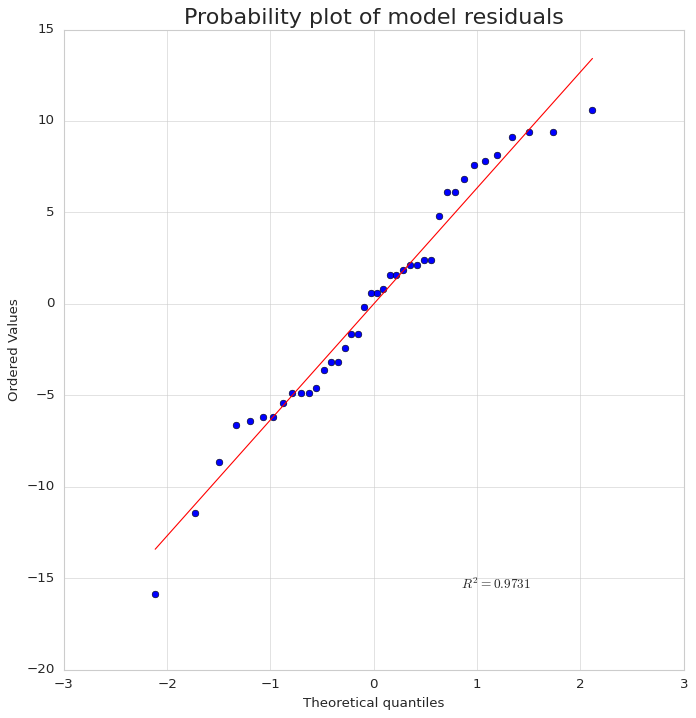

ShapiroResult(statistic=np.float64(0.9695982954527383), pvalue=np.float64(0.34949575286638046))


In [20]:
#ANOVA MODEL
vr_model = ols('Score~Method+Experience', data = vr).fit()

#Print ANOVA table
print(sm.stats.anova_lm(vr_model,typ = 2))

#For normality testing we need the scipy library
import scipy.stats as stats

#let's get the residuals
res =  vr_model.resid

#Plot for normality
fig = plt.figure(figsize= (10, 10))
ax = fig.add_subplot(111)

normality_plot, stat = stats.probplot(res, plot= plt, rvalue= True)
ax.set_title("Probability plot of model residuals", fontsize= 20)
ax.set

plt.show()

## S-W Test ##

print(stats.shapiro(res))

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Answer:**

We can see in the plot that all the vertical lines are similar height as well are randomly scattered around 0, meaning that the residuals across groups are consistent and not drastically different.

Also, the plot presented that is not outlier in the dataset, and the Breusch Pagan test *p-value* is grather  than *0.05*, for all these reasons we **failed to reject the null hypothesis** for the homogeneity assumption test.

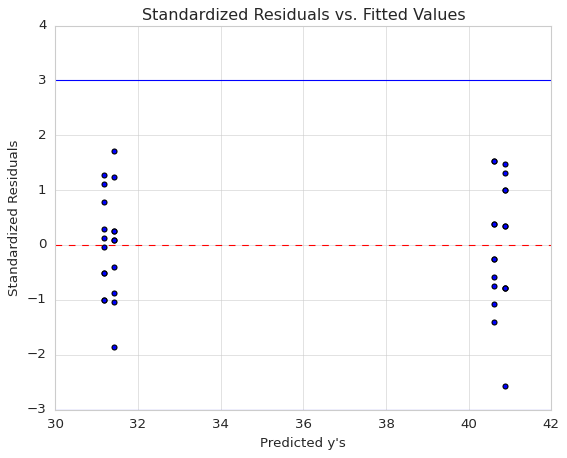

F-statistic: 1.1614606051728236
F p-value: 0.3241791601149208


In [21]:
#Check Homogeneity

# Obtain Standardized Residuals
vr_standardized_residuals = vr_model.get_influence().resid_studentized_internal

# Get the fitted values
vr_fitted_values = vr_model.fittedvalues

## Plot
plt.figure(figsize=(8, 6))
plt.scatter(vr_fitted_values, vr_standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

## B-P Test library
from statsmodels.stats.diagnostic import het_breuschpagan

#B-P Test
vr_bp_test = het_breuschpagan(vr_model.resid,vr_model.model.exog)

## Extract F-statistic ##
vr_f_statistic = vr_bp_test[2]

## Extract its P-Value ##
vr_f_p_value = vr_bp_test[3]

print(f"F-statistic: {vr_f_statistic}")
print(f"F p-value: {vr_f_p_value}")

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Answer:**

Since $F(1,37) = 21.81$  and $p < 0.001$, we would say that our data more strongly **support the alternative hypothesis** for the test.

In [22]:
#Extract value from the ANOVA table
print(sm.stats.anova_lm(vr_model,typ=2))

              sum_sq    df          F    PR(>F)
Method       893.025   1.0  21.805174  0.000039
Experience     0.625   1.0   0.015261  0.902353
Residual    1515.325  37.0        NaN       NaN


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Answer:**

Since the data and the inferential analysis strongly support the **Alternative Hypothesis**, meaning that at least one group of Methods differ from each other the Tukey's HDS post-hoc test could be performed.

The test results, displays that the Method mean differ from the Traditional and VR methods.

In [23]:
#Import neccesary library for pairwise_tukeyhsd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#Perform Tukey's HSD test
vr_tukey_result = pairwise_tukeyhsd(endog=vr['Score'], groups=vr['Method'],
                                 alpha=0.05)

print(vr_tukey_result)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
   group1   group2 meandiff p-adj lower   upper  reject
-------------------------------------------------------
Traditional     VR     9.45   0.0 5.4066 13.4934   True
-------------------------------------------------------


**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment.

**Answer:**

We can see that the p-values between the methods is less than 0.05, which would indicate that one the score group means is substantially different from the other in this population.

**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

**Answer:**

Since human participants aren't homogeneous (we naturally differ from each other) this can bring high variability to our study.

**Question 2.** What is the purpose of post-hoc tests?

**Answwer:**

Post-hoc test help to adjust the Type I error rate to maintain the desired overall significance level, $\alpha$, comparing all groups means, identifying potential significant differences.

**Question 3.** Explain the difference between RBD and LSD.

**Answer:**

The difference between RBD and LSD is that RBD just assume one nuisance factor while LSD can be implement with more than one nuisance factor.

**Question 4.** Explain why randomization is important in designing experiments.

**Answer:**

It's important because with randomization we eliminate potencial variability so we ensure that our conlusions are more accurate.

**Question 5.** Explain why replication is important in designing experiments.

**Answer:**

Replication help us to determine if treatments differences are real or just a random manifestation of the particular experimental units used in the study, since some times we have just one replicatye there is not variance  and without variance our hypoteshis test it won't work.